In [1]:
#https://www.kaggle.com/datasets/hosseinbadrnezhad/mall-customer-segmentation-dataset/data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans ,DBSCAN , AgglomerativeClustering
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.metrics import silhouette_score 
from scipy.cluster.hierarchy import dendrogram ,linkage

In [3]:
df=pd.read_csv("data.csv")

In [4]:
df.head(60)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [5]:
df.shape

(1000, 5)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [8]:
df.isnull().sum()


CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [9]:
df.dropna(inplace=True)
df.shape

(982, 5)

In [10]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

<h1>label enconder on gender</h1>

In [11]:
le=LabelEncoder()

df['Gender']=le.fit_transform(df['Gender'])
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,1,39.0,59.9,58.0
1,1001,1,34.0,48.4,37.0
2,1002,0,40.0,70.5,26.0
3,1003,0,47.0,81.1,30.0
4,1004,0,33.0,42.1,58.0


<h1>eda</h1>

<Axes: xlabel='Age', ylabel='Count'>

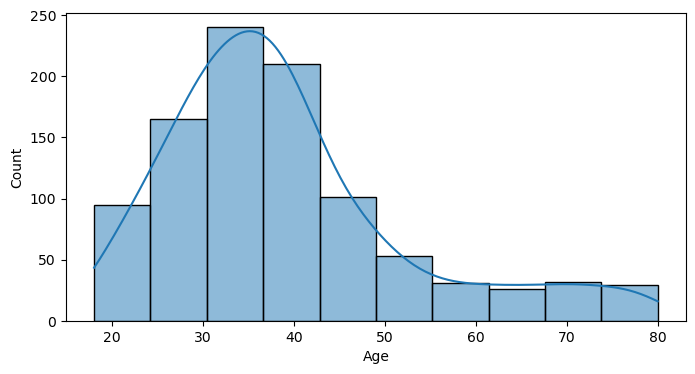

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=10,kde=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

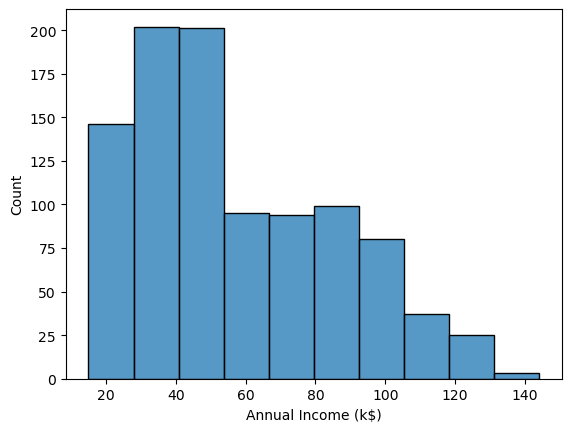

In [13]:
sns.histplot(df['Annual Income (k$)'], bins=10)

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

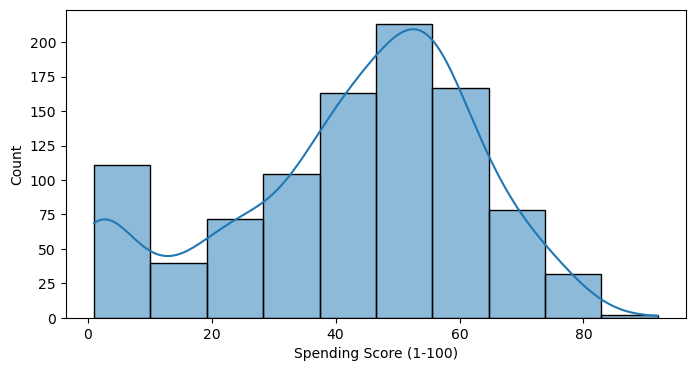

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(df['Spending Score (1-100)'], bins=10,kde=True)


<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

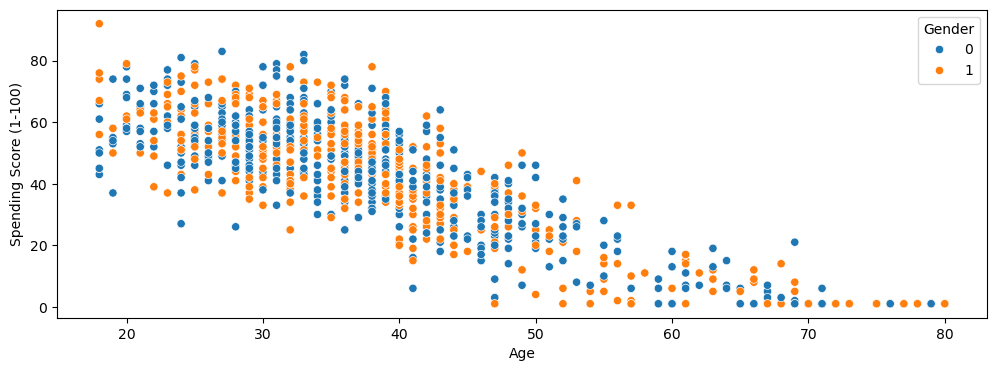

In [15]:
plt.figure(figsize=(12,4))
sns.scatterplot(x='Age', y='Spending Score (1-100)',hue='Gender', data=df)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

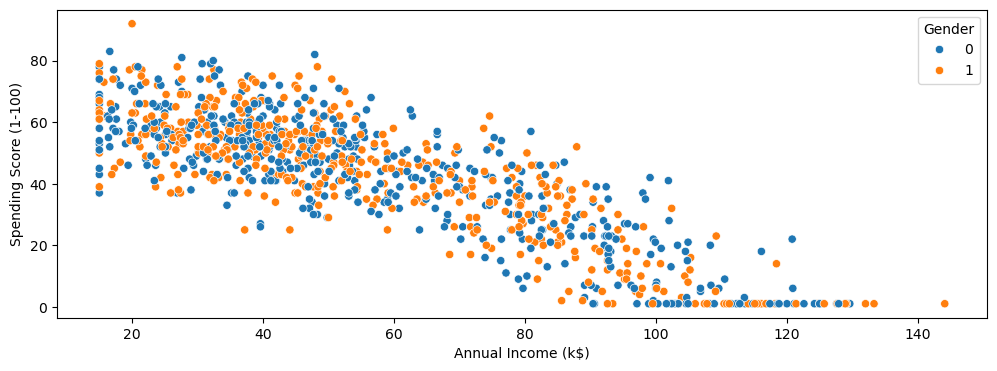

In [16]:
plt.figure(figsize=(12,4))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender',data=df)


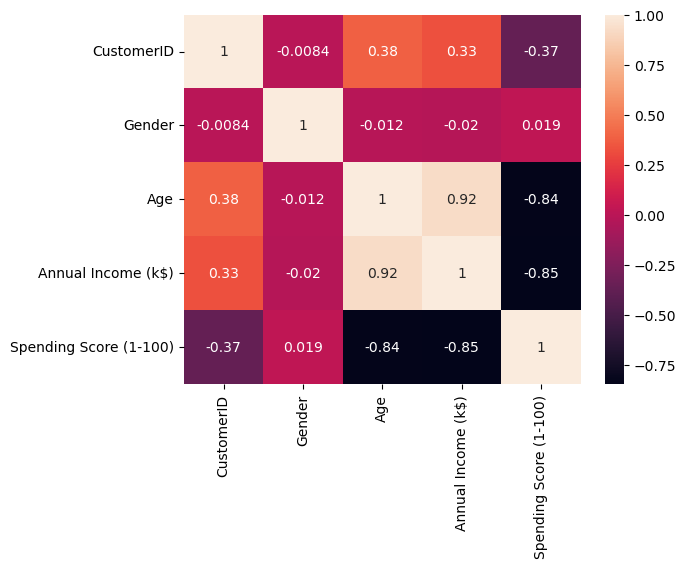

In [17]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

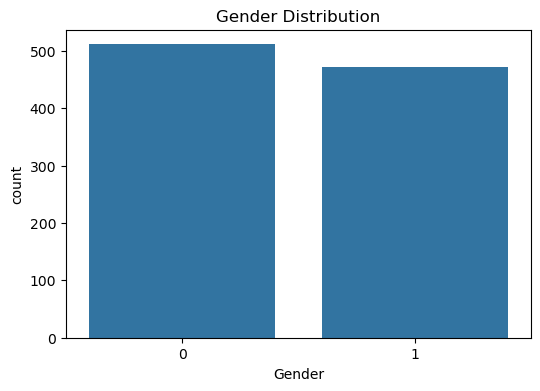

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

<outler nad iqr>

<h1>Scaling</h1>

In [19]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,1,39.0,59.9,58.0
1,1001,1,34.0,48.4,37.0
2,1002,0,40.0,70.5,26.0
3,1003,0,47.0,81.1,30.0
4,1004,0,33.0,42.1,58.0


In [20]:
X = df.drop("CustomerID", axis=1)

In [21]:
scaler =StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.04159766,  0.00311325,  0.0898333 ,  0.76554926],
       [ 1.04159766, -0.36971739, -0.31164181, -0.27864393],
       [-0.9600636 ,  0.07767938,  0.45988863, -0.82560227],
       ...,
       [-0.9600636 ,  0.52507615,  0.36213816, -0.82560227],
       [-0.9600636 , -0.81711417, -0.40590119,  0.81527275],
       [ 1.04159766,  2.09096486,  1.76206444, -2.06868941]])

<h1>elbow method</h1>

In [22]:
wcss = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

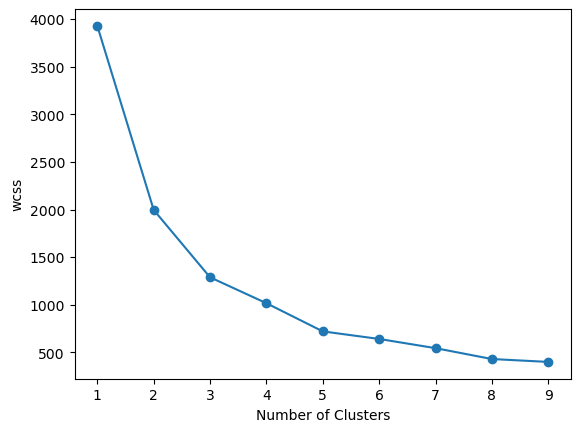

In [23]:
plt.plot(range(1,10),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("wcss")
plt.show()

<h1>silhouette Score</h1>

In [24]:
for k in range(2,6):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)
    print(f" For k:{k} silhouette Score= {score}")

 For k:2 silhouette Score= 0.5895572403593297
 For k:3 silhouette Score= 0.51029178678501
 For k:4 silhouette Score= 0.4017479958638775
 For k:5 silhouette Score= 0.35494020363988654


<h1>train the model, Kmean</h1>

In [25]:
model = KMeans(n_clusters=2)
kmean_clustering = model.fit_predict(X_scaled)


C:\Users\PRASAD\AppData\Local\Temp\ipykernel_13064\1818756097.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


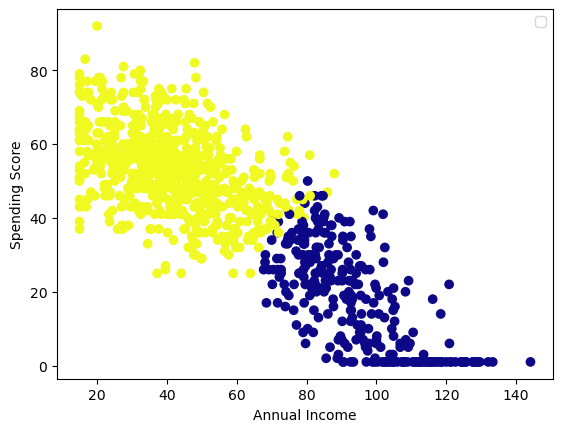

In [26]:
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c= kmean_clustering, cmap="plasma")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

<h1>Hierarchical Clustering</h1>

<h1>linkage matrix</h1>

In [27]:
linkage_matrix=linkage(df,method='ward')
linkage_matrix

array([[7.96000000e+02, 7.97000000e+02, 2.28910463e+00, 2.00000000e+00],
       [3.05000000e+02, 3.06000000e+02, 2.60000000e+00, 2.00000000e+00],
       [9.25000000e+02, 9.26000000e+02, 2.87923601e+00, 2.00000000e+00],
       ...,
       [1.95400000e+03, 1.95800000e+03, 2.96525076e+03, 4.18000000e+02],
       [1.95700000e+03, 1.95900000e+03, 4.68074746e+03, 5.64000000e+02],
       [1.96000000e+03, 1.96100000e+03, 1.09631725e+04, 9.82000000e+02]])

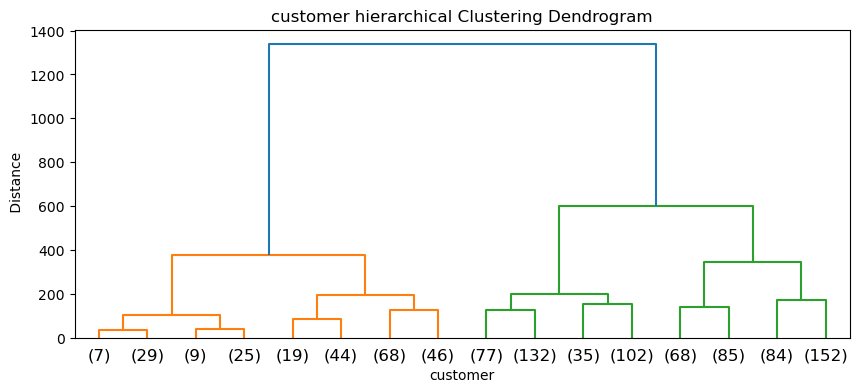

In [28]:
linked = linkage(X, method='ward')

plt.figure(figsize=(10,4))
dendrogram(linked,truncate_mode='level',p=3)
plt.title("customer hierarchical Clustering Dendrogram")
plt.xlabel("customer")
plt.ylabel(" Distance")
plt.show()

In [29]:
model = AgglomerativeClustering(n_clusters=3,linkage='ward')
labels = model.fit_predict(X_scaled)

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_13064\2094506890.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


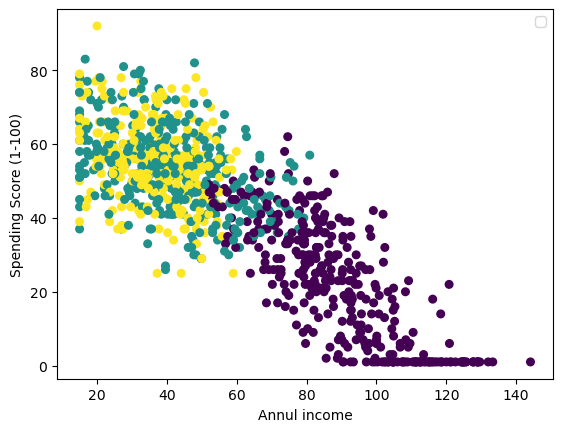

In [30]:
plt.Figure(figsize=(6,10))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],c=labels,cmap='viridis',s=30)
plt.xlabel("Annul income")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [31]:
print(np.bincount(labels))

[352 354 276]


<h1>dbscan </h1>

In [32]:
model_dbscan = DBSCAN(eps=3,min_samples=2)

labels_dbscan = model.fit_predict(X_scaled)

C:\Users\PRASAD\AppData\Local\Temp\ipykernel_13064\523220519.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


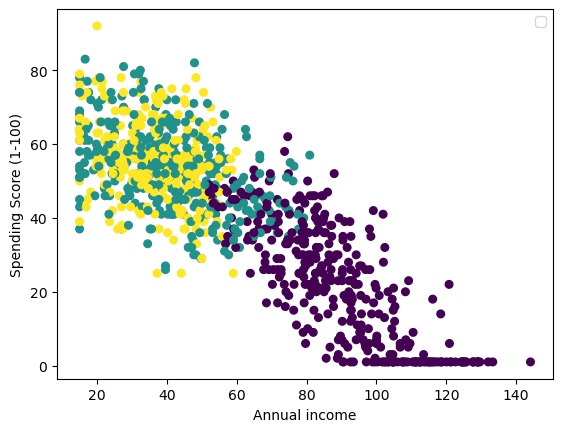

In [33]:
plt.Figure(figsize=(6,10))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],c=labels_dbscan,cmap='viridis',s=30)
plt.xlabel("Annual income")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()
plt.show()